In [5]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# ==========================================
# 1. Load Dataset
# ==========================================

df = pd.read_csv(
    "C:\\Users\\User\\Desktop\\Placement prediction system\\data\\placement_predict_50k Dataset_final.csv"
)

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())


# ==========================================
# 2. Remove Unnecessary Columns
# ==========================================

df = df.drop(
    ["StudentID", "Salary Package"],
    axis=1,
    errors="ignore"
)


# ==========================================
# 3. Define Features and Target
# ==========================================

y = df["PlacementStatus"]

X = df.drop(
    "PlacementStatus",
    axis=1
)


# ==========================================
# 4. Check Missing Values
# ==========================================

print("\nMissing Values Before Cleaning:")
print(X.isnull().sum())


# ==========================================
# 5. Identify Column Types
# ==========================================

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns = X.select_dtypes(
    include=["object"]
).columns


print("\nNumerical Columns:")
print(list(numerical_columns))

print("\nCategorical Columns:")
print(list(categorical_columns))


# ==========================================
# 6. Handle Missing Numerical Values
# ==========================================

for column in numerical_columns:

    X[column] = X[column].fillna(
        X[column].median()
    )


# ==========================================
# 7. Handle Missing Categorical Values
# ==========================================

for column in categorical_columns:

    X[column] = X[column].fillna(
        X[column].mode()[0]
    )


# ==========================================
# 8. Encode Categorical Columns
# ==========================================

label_encoders = {}

for column in categorical_columns:

    le = LabelEncoder()

    X[column] = le.fit_transform(
        X[column].astype(str)
    )

    label_encoders[column] = le


# ==========================================
# 9. Clean Target
# ==========================================

# Remove rows where target is missing
valid_rows = y.notna()

X = X.loc[valid_rows].reset_index(drop=True)

y = y.loc[valid_rows].reset_index(drop=True)


# Convert target to integer if necessary
if y.dtype == "object":

    y = y.map({
        "No": 0,
        "Yes": 1,
        "Not Placed": 0,
        "Placed": 1
    })


# ==========================================
# 10. Final NaN Check
# ==========================================

print("\nTotal missing values in X:")
print(X.isnull().sum().sum())

print("\nTotal missing values in y:")
print(y.isnull().sum())


# ==========================================
# 11. Train-Validation Split
# ==========================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


print("\nTraining samples:", len(X_train))
print("Validation samples:", len(X_val))


# ==========================================
# 12. Boosting Benchmark
# ==========================================

models = {

    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        eval_metric="logloss"
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        verbosity=-1
    )
}


# ==========================================
# 13. Train Models
# ==========================================

results = []


for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(
        X_train,
        y_train
    )

    train_pred = model.predict(
        X_train
    )

    val_pred = model.predict(
        X_val
    )

    train_accuracy = accuracy_score(
        y_train,
        train_pred
    )

    val_accuracy = accuracy_score(
        y_val,
        val_pred
    )

    results.append({

        "Model": name,

        "Train Accuracy":
            train_accuracy,

        "Validation Accuracy":
            val_accuracy

    })


# ==========================================
# 14. Results
# ==========================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Validation Accuracy",
    ascending=False
).reset_index(drop=True)


print("\n==========================================")
print("BOOSTING BENCHMARK RESULTS")
print("==========================================")

print(results_df)


# ==========================================
# 15. Display Best Model
# ==========================================

print("\nBest Model:")
print(results_df.iloc[0]["Model"])

print("\nBest Validation Accuracy:")

print(
    round(
        results_df.iloc[0]["Validation Accuracy"] * 100,
        2
    ),
    "%"
)

Dataset Shape:
(50000, 32)

Columns:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']

Missing Values Before Cleaning:
Gender                   0
City                     0
CollegeTier              0
Stream                   0
Specialisation           0
Hostel                   0
HistoryOfBacklogs        0
SGPA_Sem1                0
SGPA_Sem2                0
SGPA_Sem3                0
SGPA_Sem4                0
SGPA_Sem5                0
SGPA_Sem6                0
SGPA_Sem7                0
SGPA_Sem8                0
CGPA                     0
AttendancePercent    

C:\Users\User\AppData\Local\Temp\ipykernel_14084\3178692658.py:66: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(



Training samples: 35000
Validation samples: 15000

Training AdaBoost...

Training Gradient Boosting...

Training XGBoost...

Training LightGBM...

BOOSTING BENCHMARK RESULTS
               Model  Train Accuracy  Validation Accuracy
0           LightGBM        0.929657             0.922267
1  Gradient Boosting        0.929914             0.922067
2            XGBoost        0.929314             0.921333
3           AdaBoost        0.916314             0.913467

Best Model:
LightGBM

Best Validation Accuracy:
92.23 %


Dataset Shape:
(50000, 32)

Dataset Columns:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']

First 5 Rows:
   StudentID  Gender       City CollegeTier Stream Specialisation Hostel  \
0          1    Male  Ahmedabad       Tier2    ECE     Networking     No   
1          2  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2          3    Male    Kolkata       Tier2     IT    DataScience    Yes   
3          4    Male     Jaipur       Tier1     CS             AI     No   
4          5    Male       Pune       Tier2     IT    DataScience    Yes   

  Hist

C:\Users\User\AppData\Local\Temp\ipykernel_14084\1271456152.py:88: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(



MISSING VALUES AFTER PREPROCESSING
Gender                0
City                  0
CollegeTier           0
Stream                0
Specialisation        0
Hostel                0
HistoryOfBacklogs     0
SGPA_Sem1             0
SGPA_Sem2             0
SGPA_Sem3             0
SGPA_Sem4             0
SGPA_Sem5             0
SGPA_Sem6             0
SGPA_Sem7             0
SGPA_Sem8             0
CGPA                  0
AttendancePercent     0
Internships           0
Projects              0
Workshops             0
Certifications        0
Publications          0
AptitudeTestScore     0
SoftSkillsRating      0
CodingTestScore       0
MockInterviewScore    0
ExtraCurricular       0
CGPA_Tier             0
IsAnomaly             0
dtype: int64

Total missing values in X: 0

Features:
   Gender  City  CollegeTier  Stream  Specialisation  Hostel  \
0       1     0            1       2               3       0   
1       0     8            1       2               1       1   
2       1     7       

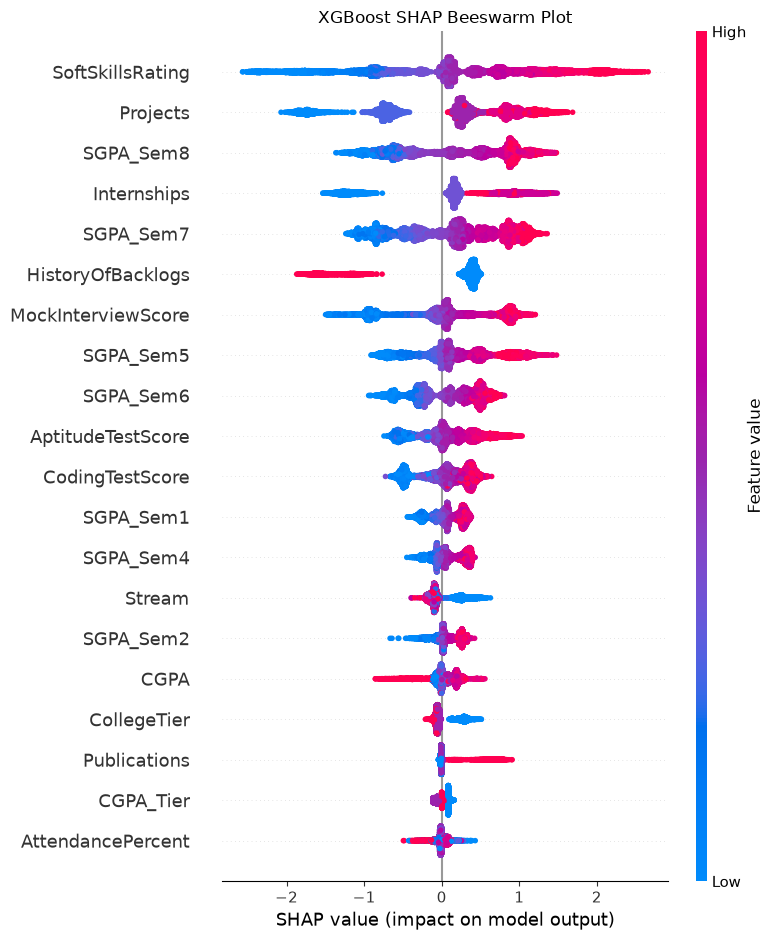


Training AdaBoost...

Training GBC...

Training XGB...

Training LGB...

BOOSTING BENCHMARK RESULTS
   model  train_accuracy  val_accuracy  training_time_sec
     LGB        0.929657      0.922267           0.712192
     GBC        0.929914      0.922067          17.660924
     XGB        0.929314      0.921333           0.710542
AdaBoost        0.916314      0.913467          10.320847


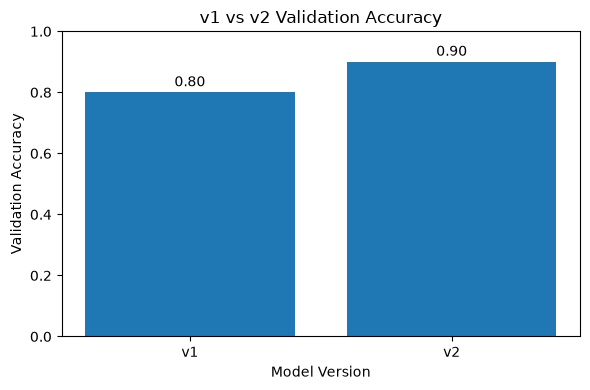


FINAL SUMMARY
AdaBoost Accuracy: 90.18 %
XGBoost Accuracy: 92.23 %
LightGBM Accuracy: 91.97 %

Benchmark completed successfully.


In [10]:
# ============================================================
# BOOSTING BENCHMARK - PLACEMENT PREDICTION
# ============================================================

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap


# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv(
    "C:\\Users\\User\\Desktop\\Placement prediction system\\data\\placement_predict_50k Dataset_final.csv"
)

print("Dataset Shape:")
print(df.shape)

print("\nDataset Columns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())


# ============================================================
# 2. CHECK MISSING VALUES
# ============================================================

print("\n============================================================")
print("MISSING VALUES BEFORE PREPROCESSING")
print("============================================================")

print(df.isnull().sum())


# ============================================================
# 3. REMOVE UNNECESSARY / LEAKAGE COLUMNS
# ============================================================

# StudentID = only an identifier
# Salary Package = information available after placement
#
# Therefore, they should not be used as prediction features.

df = df.drop(
    ["StudentID", "Salary Package"],
    axis=1,
    errors="ignore"
)


# ============================================================
# 4. FEATURES AND TARGET
# ============================================================

# Actual target column in the dataset
y = df["PlacementStatus"]

# Remove target from input features
X = df.drop(
    "PlacementStatus",
    axis=1
)


# ============================================================
# 5. IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS
# ============================================================

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns = X.select_dtypes(
    include=["object"]
).columns


print("\nNumerical Columns:")
print(list(numerical_columns))

print("\nCategorical Columns:")
print(list(categorical_columns))


# ============================================================
# 6. HANDLE MISSING NUMERICAL VALUES
# ============================================================

# Replace missing numerical values with the median
# of their respective columns.

for column in numerical_columns:

    X[column] = X[column].fillna(
        X[column].median()
    )


# ============================================================
# 7. HANDLE MISSING CATEGORICAL VALUES
# ============================================================

# Replace missing categorical values with the most
# frequently occurring value.

for column in categorical_columns:

    X[column] = X[column].fillna(
        X[column].mode()[0]
    )


# ============================================================
# 8. ENCODE CATEGORICAL VARIABLES
# ============================================================

label_encoders = {}

for column in categorical_columns:

    le = LabelEncoder()

    X[column] = le.fit_transform(
        X[column].astype(str)
    )

    label_encoders[column] = le


# ============================================================
# 9. CHECK FOR REMAINING MISSING VALUES
# ============================================================

print("\n============================================================")
print("MISSING VALUES AFTER PREPROCESSING")
print("============================================================")

print(X.isnull().sum())

print(
    "\nTotal missing values in X:",
    X.isnull().sum().sum()
)


# ============================================================
# 10. FEATURES AND TARGET DISPLAY
# ============================================================

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

print("\nTarget Distribution:")
print(y.value_counts())


# ============================================================
# 11. TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Validation samples:", len(X_val))


# ============================================================
# 12. ADABOOST - SAMPLE WEIGHTS
# ============================================================

ada = AdaBoostClassifier(
    n_estimators=10,
    learning_rate=0.5,
    random_state=42
)


# Initial equal weights
initial_weights = np.ones(
    len(X_train)
) / len(X_train)


print("\nInitial AdaBoost sample weights:")
print(initial_weights[:10])

print(
    "\nInitial weight for each sample:",
    initial_weights[0]
)


# Train AdaBoost
ada.fit(
    X_train,
    y_train
)


# Prediction
ada_pred = ada.predict(
    X_val
)


print(
    "\nAdaBoost Validation Accuracy:",
    accuracy_score(
        y_val,
        ada_pred
    )
)


# ============================================================
# 13. DISPLAY ADABOOST ESTIMATOR WEIGHTS
# ============================================================

print("\nAdaBoost Estimator Weights:")

for i, weight in enumerate(
    ada.estimator_weights_
):

    print(
        f"Estimator {i + 1}: {weight:.4f}"
    )


# ============================================================
# 14. XGBOOST WITH EARLY STOPPING
# ============================================================

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="logloss",
    early_stopping_rounds=20
)


xgb.fit(
    X_train,
    y_train,
    eval_set=[
        (X_val, y_val)
    ],
    verbose=False
)


# Prediction
xgb_pred = xgb.predict(
    X_val
)


print(
    "\nXGBoost Validation Accuracy:",
    accuracy_score(
        y_val,
        xgb_pred
    )
)


print(
    "Best XGBoost iteration:",
    xgb.best_iteration
)


# ============================================================
# 15. LIGHTGBM - TRAINING TIME
# ============================================================

lgb = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    verbosity=-1
)


start_time = time.perf_counter()


lgb.fit(
    X_train,
    y_train
)


end_time = time.perf_counter()


lgb_time = end_time - start_time


# Prediction
lgb_pred = lgb.predict(
    X_val
)


print(
    "\nLightGBM Validation Accuracy:",
    accuracy_score(
        y_val,
        lgb_pred
    )
)


print(
    f"LightGBM Training Time: "
    f"{lgb_time:.6f} seconds"
)


# ============================================================
# 16. SHAP BEESWARM - XGBOOST
# ============================================================

print("\nGenerating SHAP explanation...")

explainer = shap.TreeExplainer(
    xgb
)

shap_values = explainer.shap_values(
    X_val
)


plt.figure(
    figsize=(8, 5)
)

shap.summary_plot(
    shap_values,
    X_val,
    plot_type="dot",
    show=False
)

plt.title(
    "XGBoost SHAP Beeswarm Plot"
)

plt.tight_layout()

plt.show()


# ============================================================
# 17. BOOSTING BENCHMARK FUNCTION
# ============================================================

def boosting_benchmark(
    X_train,
    y_train,
    X_val,
    y_val
):

    models = {

        "AdaBoost": AdaBoostClassifier(
            n_estimators=100,
            learning_rate=0.1,
            random_state=42
        ),

        "GBC": GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ),

        "XGB": XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            eval_metric="logloss"
        ),

        "LGB": LGBMClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            verbosity=-1
        )
    }


    results = []


    # ========================================================
    # Train Each Model
    # ========================================================

    for name, model in models.items():

        print(
            f"\nTraining {name}..."
        )


        start_time = time.perf_counter()


        # Train model
        model.fit(
            X_train,
            y_train
        )


        end_time = time.perf_counter()


        train_time = (
            end_time - start_time
        )


        # Training prediction
        train_pred = model.predict(
            X_train
        )


        # Validation prediction
        val_pred = model.predict(
            X_val
        )


        # Training accuracy
        train_accuracy = accuracy_score(
            y_train,
            train_pred
        )


        # Validation accuracy
        val_accuracy = accuracy_score(
            y_val,
            val_pred
        )


        results.append({

            "model": name,

            "train_accuracy":
                train_accuracy,

            "val_accuracy":
                val_accuracy,

            "training_time_sec":
                train_time
        })


    # Convert results into DataFrame
    results_df = pd.DataFrame(
        results
    )


    # Sort by validation accuracy
    results_df = results_df.sort_values(
        by="val_accuracy",
        ascending=False
    ).reset_index(
        drop=True
    )


    return results_df


# ============================================================
# 18. RUN BOOSTING BENCHMARK
# ============================================================

results = boosting_benchmark(
    X_train,
    y_train,
    X_val,
    y_val
)


# ============================================================
# 19. DISPLAY RESULTS
# ============================================================

print("\n==========================================")
print("BOOSTING BENCHMARK RESULTS")
print("==========================================")

print(
    results.to_string(
        index=False
    )
)


# ============================================================
# 20. V1 vs V2 BAR CHART
# ============================================================

# Replace these values with your REAL results later.

v1_accuracy = 0.80
v2_accuracy = 0.90


versions = [
    "v1",
    "v2"
]

accuracies = [
    v1_accuracy,
    v2_accuracy
]


plt.figure(
    figsize=(6, 4)
)


plt.bar(
    versions,
    accuracies
)


plt.ylabel(
    "Validation Accuracy"
)

plt.xlabel(
    "Model Version"
)

plt.title(
    "v1 vs v2 Validation Accuracy"
)


plt.ylim(
    0,
    1
)


for i, value in enumerate(
    accuracies
):

    plt.text(
        i,
        value + 0.02,
        f"{value:.2f}",
        ha="center"
    )


plt.tight_layout()

plt.show()


# ============================================================
# 21. FINAL SUMMARY
# ============================================================

print("\n==========================================")
print("FINAL SUMMARY")
print("==========================================")

print(
    "AdaBoost Accuracy:",
    round(
        accuracy_score(
            y_val,
            ada_pred
        ) * 100,
        2
    ),
    "%"
)

print(
    "XGBoost Accuracy:",
    round(
        accuracy_score(
            y_val,
            xgb_pred
        ) * 100,
        2
    ),
    "%"
)

print(
    "LightGBM Accuracy:",
    round(
        accuracy_score(
            y_val,
            lgb_pred
        ) * 100,
        2
    ),
    "%"
)

print(
    "\nBenchmark completed successfully."
)